In [1]:
import numpy as np
import xarray as xr

fname1 = "data/etna2018-128.ens.nc"
fname2 = "output/posterior_samples_vae07.nc"
fname3 = "data/20181224_1800_Meteosat-11_Etna_VPRoutput.nc"

ds1 = xr.open_dataset(fname1)
ds2 = xr.open_dataset(fname2)
ds3 = xr.open_dataset(fname3)

da1 = ds1['tephra_col_mass'].mean(dim='ens')
da2 = ds2['mean']
da3 = ds3['mass']

# Closed loop coordinates for the domain box
lat1 = ds1.lat.minimum
lat2 = ds1.lat.maximum
lon1 = ds1.lon.minimum
lon2 = ds1.lon.maximum
box_lons = [lon1, lon2, lon2, lon1, lon1]
box_lats = [lat1, lat1, lat2, lat2, lat1]

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from modules.plot import get_cbar_size, set_map

## Plotting ensemble mean

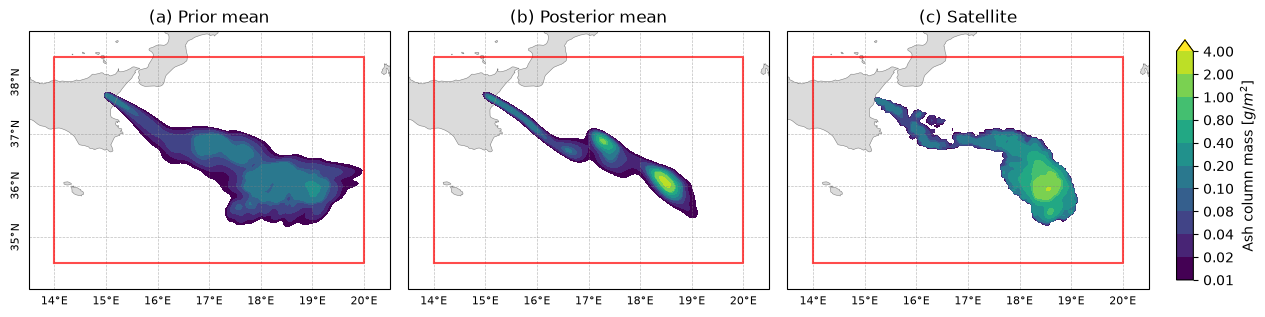

In [3]:
# 1. Initialize subplots
fig, axs = plt.subplots(
    nrows=1, 
    ncols=3,
    subplot_kw={'projection': ccrs.PlateCarree()}, 
    figsize=(14, 6)
)

# 2. Setup discrete levels & consecutive colors mapping
levels = [1E-2, 2E-2, 4E-2, 8E-2, 1E-1, 2E-1, 4E-1, 8E-1, 1, 2, 4]
cmap = plt.get_cmap('viridis', len(levels))
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N, extend='max')

conf = {
    'levels': levels,
    'cmap': cmap,
    'norm': norm,
    'extend': 'max'
}

# Plot contours
cf = axs[0].contourf(ds1.lon, ds1.lat, da1, **conf)
cf = axs[1].contourf(ds1.lon, ds1.lat, da2, **conf)
cf = axs[2].contourf(ds3.longitude, ds3.latitude, da3, **conf)

titles = ['(a) Prior mean', '(b) Posterior mean', '(c) Satellite']

for i, ax in enumerate(axs.flat):
    set_map(ax)
    
    ax.set_extent([13.5, 20.5, 34, 39], crs=ccrs.PlateCarree())

    # --- ADD DOMAIN BOUNDING BOX ---
    ax.plot(
        box_lons, 
        box_lats, 
        color='red', 
        linewidth=1.5, 
        linestyle='-', 
        transform=ccrs.PlateCarree(),
        alpha = 0.7,
        zorder=5  # Keep box on top of filled contours
    )

    active_labels = ['bottom', 'left'] if i == 0 else ['bottom']
    
    # Gridlines configuration
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=active_labels,
        linewidth=0.5,
        color='gray',
        alpha=0.5,
        linestyle='--'
    )
    
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'rotation': 89, 'size': 8}
    
    # Set titles
    ax.set_title(titles[i])

# 3. Reserve space on right and place a dedicated vertical colorbar axis
fig.subplots_adjust(left=0.06, right=0.86, top=0.85, bottom=0.15, wspace=0.05)

cbar_bottom_y, cbar_width, cbar_height = get_cbar_size(axs[2])
cbar_ax = fig.add_axes([0.88, cbar_bottom_y, cbar_width, cbar_height]) 
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='vertical', ticks=levels)
cbar.set_label(r'Ash column mass [$g/m^2$]', fontsize=10)